In [43]:
import bk_tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from bk_tools import BASE_DIR
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# Import all necessary libraries for data manipulation, visualization and deep learning.

In [44]:
# Prepare the data table using the custom function from bk_tools and display its information.

df = bk_tools.prepare_data_table()
df.info()

df["class"].unique()


DataFrame shape: (7909, 8)
DataFrame columns: ['patient_id', 'file_id', 'example', 'class', 'year', 'zoom', 'file_path', 'is_malign']
Parsed files: 7909
Failed files: 0
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


<StringArray>
['A', 'F', 'PT', 'TA', 'DC', 'LC', 'MC', 'PC']
Length: 8, dtype: str

In [45]:
# Prepare the data splitting for the chosen zoom level (200) and display the class distribution in the validation set.
train_df, val_df, test_df = bk_tools.prepare_image_level_split(
    df=df,
    chosen_zoom=400,
    test_size=0.2,
    val_size=0.2,
)
print(val_df["class"].value_counts())


Selected zoom: 400
Total images: 1820

Class distribution before split:
class
DC    788
F     237
MC    169
PC    138
LC    137
TA    130
PT    115
A     106
Name: count, dtype: int64

Split sizes:
Train: 1092
Val  : 364
Test : 364

Train class distribution:
class
DC    473
F     142
MC    101
PC     83
LC     82
TA     78
PT     69
A      64
Name: count, dtype: int64

Val class distribution:
class
DC    157
F      48
MC     34
PC     28
LC     27
TA     26
PT     23
A      21
Name: count, dtype: int64

Test class distribution:
class
DC    158
F      47
MC     34
LC     28
PC     27
TA     26
PT     23
A      21
Name: count, dtype: int64

Patient overlap check (expected in image-level split):
Train-Val overlap : 79
Train-Test overlap: 79
Val-Test overlap  : 77
class
DC    157
F      48
MC     34
PC     28
LC     27
TA     26
PT     23
A      21
Name: count, dtype: int64


In [46]:
CLASS_NAMES = ['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

train_df["label"] = train_df["class"].map(class_to_idx)
val_df["label"] = val_df["class"].map(class_to_idx)
test_df["label"] = test_df["class"].map(class_to_idx)



In [47]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 8
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.07),
    tf.keras.layers.RandomContrast(0.07),
], name="augmentation")

In [48]:

def make_dataset(df, training=False):
    image_paths = df["file_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [49]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [50]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, EfficientNetB1

def build_pretrained_sequential_model(input_shape=(224, 224, 3), num_classes=8):
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = True
    

    for layer in base_model.layers[:-55]:
        layer.trainable = False

    model = models.Sequential([
        tf.keras.Input(shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model, base_model

In [51]:
from bk_tools import BASE_DIR


model, base_model = build_pretrained_sequential_model(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

MODEL_DIR = BASE_DIR/"models"
MODEL_DIR.mkdir(exist_ok=True)

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_DIR / "best_model_classification.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,698,760 (29.37 MB)

 Trainable params: 1,774,088 (6.77 MB)

 Non-trainable params: 5,924,672 (22.60 MB)

In [52]:
# Set up callbacks for learning rate reduction, early stopping, and model checkpointing during training.




y_train = train_df["label"].values.astype(int)

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {cls: weight for cls, weight in zip(classes, weights)}


class_weight = {
    0: 1.2,   # MC
    1: 1.2,   # PC
    2: 1.0,   # DC
    3: 1.2,   # LC
    4: 1.3,   # A
    5: 1.2,   # TA
    6: 1.0,   # F
    7: 1.3    # PT
}



print("Class weights:")
print(class_weight)



# Train the model using the fit method with the training and validation generators, class weights, and callbacks.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    class_weight=class_weight,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Class weights:
{0: 1.2, 1: 1.2, 2: 1.0, 3: 1.2, 4: 1.3, 5: 1.2, 6: 1.0, 7: 1.3}
Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 867ms/step - accuracy: 0.1166 - loss: 3.5243 - top2_acc: 0.2408
Epoch 1: val_loss improved from None to 2.51765, saving model to C:\Users\sarpustacom\ASIL_Lab\Courses_Assignments\BreastCancerV1\models\best_model_classification.keras

Epoch 1: finished saving model to C:\Users\sarpustacom\ASIL_Lab\Courses_Assignments\BreastCancerV1\models\best_model_classification.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.1310 - loss: 3.3921 - top2_acc: 0.2555 - val_accuracy: 0.0412 - val_loss: 2.5177 - val_top2_acc: 0.1896 - learning_rate: 5.0000e-06
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.1562 - loss: 3.1976 - top2_acc: 0.2858
Epoch 2: val_loss improved from 2.51765 to 2.20406, saving model to C:\Users\sarpustacom\ASIL_Lab\Courses_Assignments\BreastCancerV1\models\best_model_classification.keras

Epoch 2: finished saving model to C:\Users\s

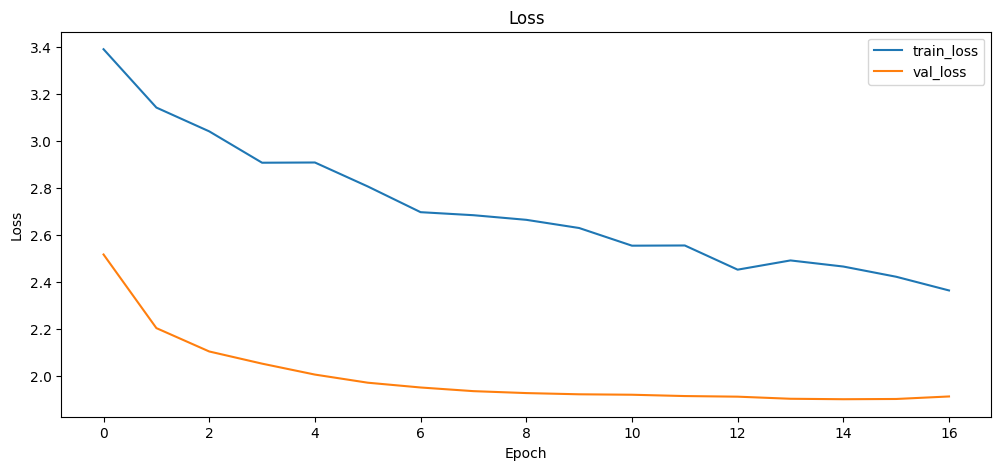

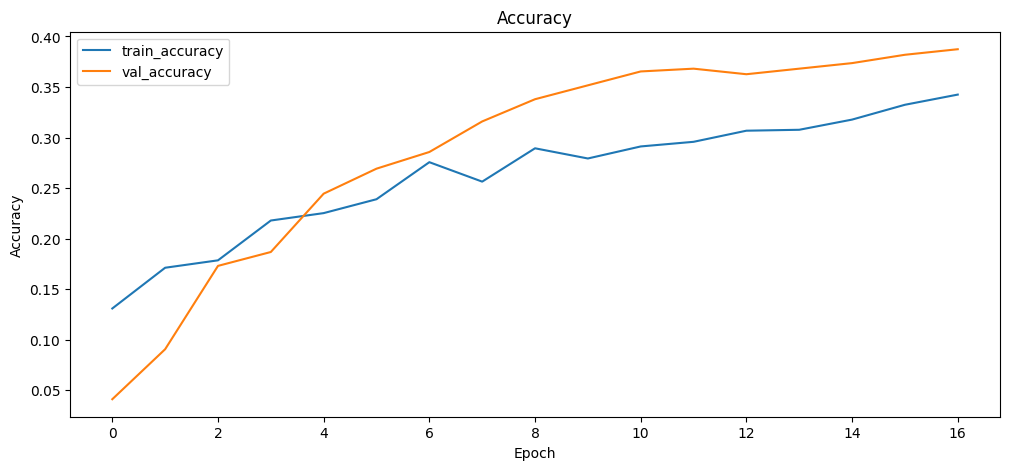

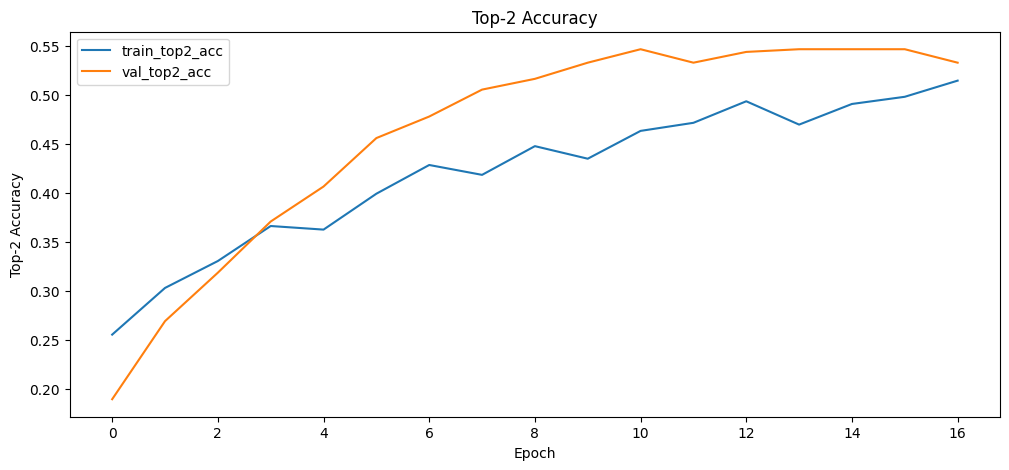

In [53]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    history_dict = history.history

    plt.figure(figsize=(12, 5))
    plt.plot(history_dict["loss"], label="train_loss")
    plt.plot(history_dict["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(history_dict["accuracy"], label="train_accuracy")
    plt.plot(history_dict["val_accuracy"], label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    if "top2_acc" in history_dict and "val_top2_acc" in history_dict:
        plt.figure(figsize=(12, 5))
        plt.plot(history_dict["top2_acc"], label="train_top2_acc")
        plt.plot(history_dict["val_top2_acc"], label="val_top2_acc")
        plt.title("Top-2 Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Top-2 Accuracy")
        plt.legend()
        plt.show()

plot_training_history(history)

In [54]:
test_loss, test_acc, test_top2 = model.evaluate(test_ds, verbose=1)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Top-2 Acc: {test_top2:.4f}")



y_true = test_df["label"].values
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 536ms/step - accuracy: 0.3956 - loss: 1.9083 - top2_acc: 0.5385
Test Loss     : 1.9083
Test Accuracy : 0.3956
Test Top-2 Acc: 0.5385
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 782ms/step


In [55]:
from sklearn.metrics import classification_report

CLASS_NAMES = ['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

          MC     0.3269    0.5000    0.3953        34
          PC     0.1481    0.1481    0.1481        27
          DC     0.7925    0.5316    0.6364       158
          LC     0.1852    0.1786    0.1818        28
           A     0.0000    0.0000    0.0000        21
          TA     0.2000    0.1538    0.1739        26
           F     0.3514    0.5532    0.4298        47
          PT     0.1000    0.1739    0.1270        23

    accuracy                         0.3956       364
   macro avg     0.2630    0.2799    0.2615       364
weighted avg     0.4657    0.3956    0.4141       364



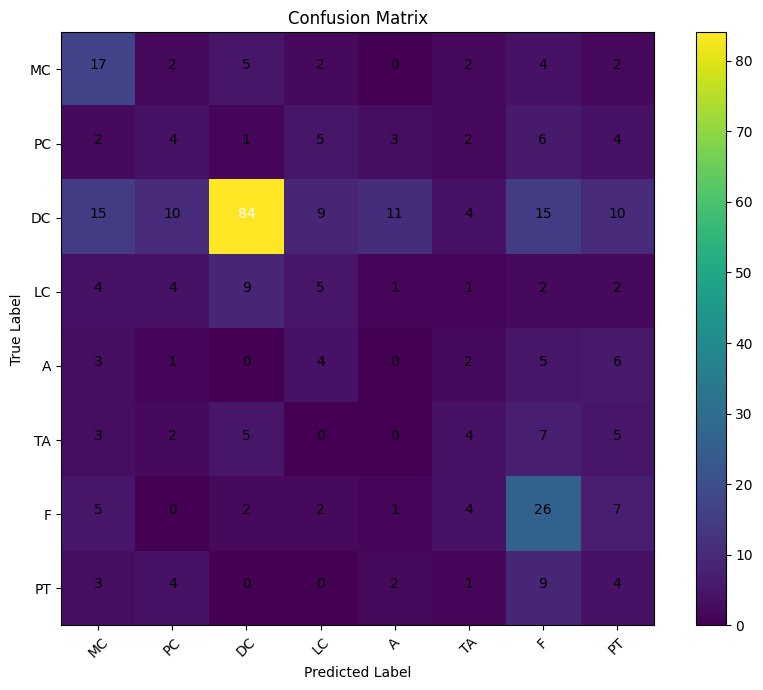

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(9, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, CLASS_NAMES)